# Thesis Notebook 10 — Dataset & Target EDA

Establishes dataset validity, target difficulty, and split integrity for the final aligned multimodal dataset.

**Covers:**
- Train / val / test split size verification
- Per-target distribution across splits (stationarity check)
- Inter-target correlation (label independence)
- Genre and release-year coverage (domain breadth)
- Artist-aware split sanity check (data leakage audit)

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Repo root — works when notebook lives in notebooks/
REPO = Path().resolve().parent
DATA = REPO / 'data' / 'processed'
FEATURES = REPO / 'ml' / 'features'
FIGS = REPO / 'results' / 'figures' / 'thesis'
FIGS.mkdir(parents=True, exist_ok=True)

TARGETS = ['valence', 'energy', 'danceability', 'popularity']
SPLITS  = ['train', 'val', 'test']
SPLIT_COLORS = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

# Thesis-ready style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

print('REPO:', REPO)
print('DATA:', DATA)
print('FIGS:', FIGS)

REPO: /home/esstee/projects/music-prediction
DATA: /home/esstee/projects/music-prediction/data/processed
FIGS: /home/esstee/projects/music-prediction/results/figures/thesis


## 1. Load Split CSVs

Load the pre-computed train / val / test partitions from `data/processed/`. Report shapes and confirm all target columns are present.

In [3]:
dfs = {}
for split in SPLITS:
    path = DATA / f'{split}.csv'
    dfs[split] = pd.read_csv(path)
    print(f'{split:>5}: {dfs[split].shape[0]:>8,} rows  x  {dfs[split].shape[1]} cols')

# Confirm columns
print('\nColumns:', list(dfs['train'].columns))

# Detect artist and genre column names defensively
_cols = dfs['train'].columns.tolist()
ARTIST_COL = 'artists' if 'artists' in _cols else 'artist'
GENRE_COL  = 'genre'   if 'genre'   in _cols else 'track_genre'
YEAR_COL   = 'year'    if 'year'    in _cols else 'release_date'
print(f'\nUsing: artist={ARTIST_COL!r}, genre={GENRE_COL!r}, year={YEAR_COL!r}')

# Verify targets exist
for t in TARGETS:
    assert t in _cols, f'Target column {t!r} missing!'
print('All target columns verified:', TARGETS)

train:  344,428 rows  x  24 cols
  val:   72,631 rows  x  24 cols
 test:   74,573 rows  x  24 cols

Columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']

Using: artist='artists', genre='genre', year='year'
All target columns verified: ['valence', 'energy', 'danceability', 'popularity']


## 2. Figure 1 — Split Size Distribution

Horizontal bar chart showing the number of samples in each split, annotated with counts and percentages.

/tmp/ipykernel_8006/2006122330.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Train', 'Val', 'Test'])


Saved: /home/esstee/projects/music-prediction/results/figures/thesis/10_split_sizes.png


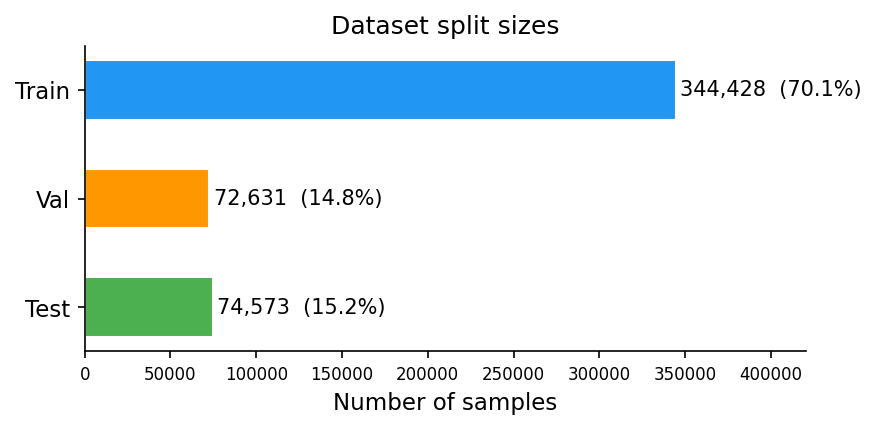

In [4]:
counts = {s: len(dfs[s]) for s in SPLITS}
total  = sum(counts.values())

fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.barh(
    SPLITS,
    [counts[s] for s in SPLITS],
    color=[SPLIT_COLORS[s] for s in SPLITS],
    edgecolor='white',
    height=0.55,
)

for bar, split in zip(bars, SPLITS):
    n   = counts[split]
    pct = 100 * n / total
    ax.text(
        bar.get_width() + total * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{n:,}  ({pct:.1f}%)',
        va='center', ha='left', fontsize=10,
    )

ax.set_xlabel('Number of samples')
ax.tick_params(axis='x', labelsize=8) 
ax.set_title('Dataset split sizes')
ax.set_xlim(0, max(counts.values()) * 1.22)
ax.set_yticklabels(['Train', 'Val', 'Test'])
ax.invert_yaxis()

plt.tight_layout()
out = FIGS / '10_split_sizes.png'
fig.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

## 3. Figure 2 — Target Distributions by Split

A 4 × 3 grid (4 targets × 3 splits) showing KDE plots for each target–split combination.
Consistent split colours allow visual stationarity assessment across partitions.

Saved: /home/esstee/projects/music-prediction/results/figures/thesis/10_target_distributions.png


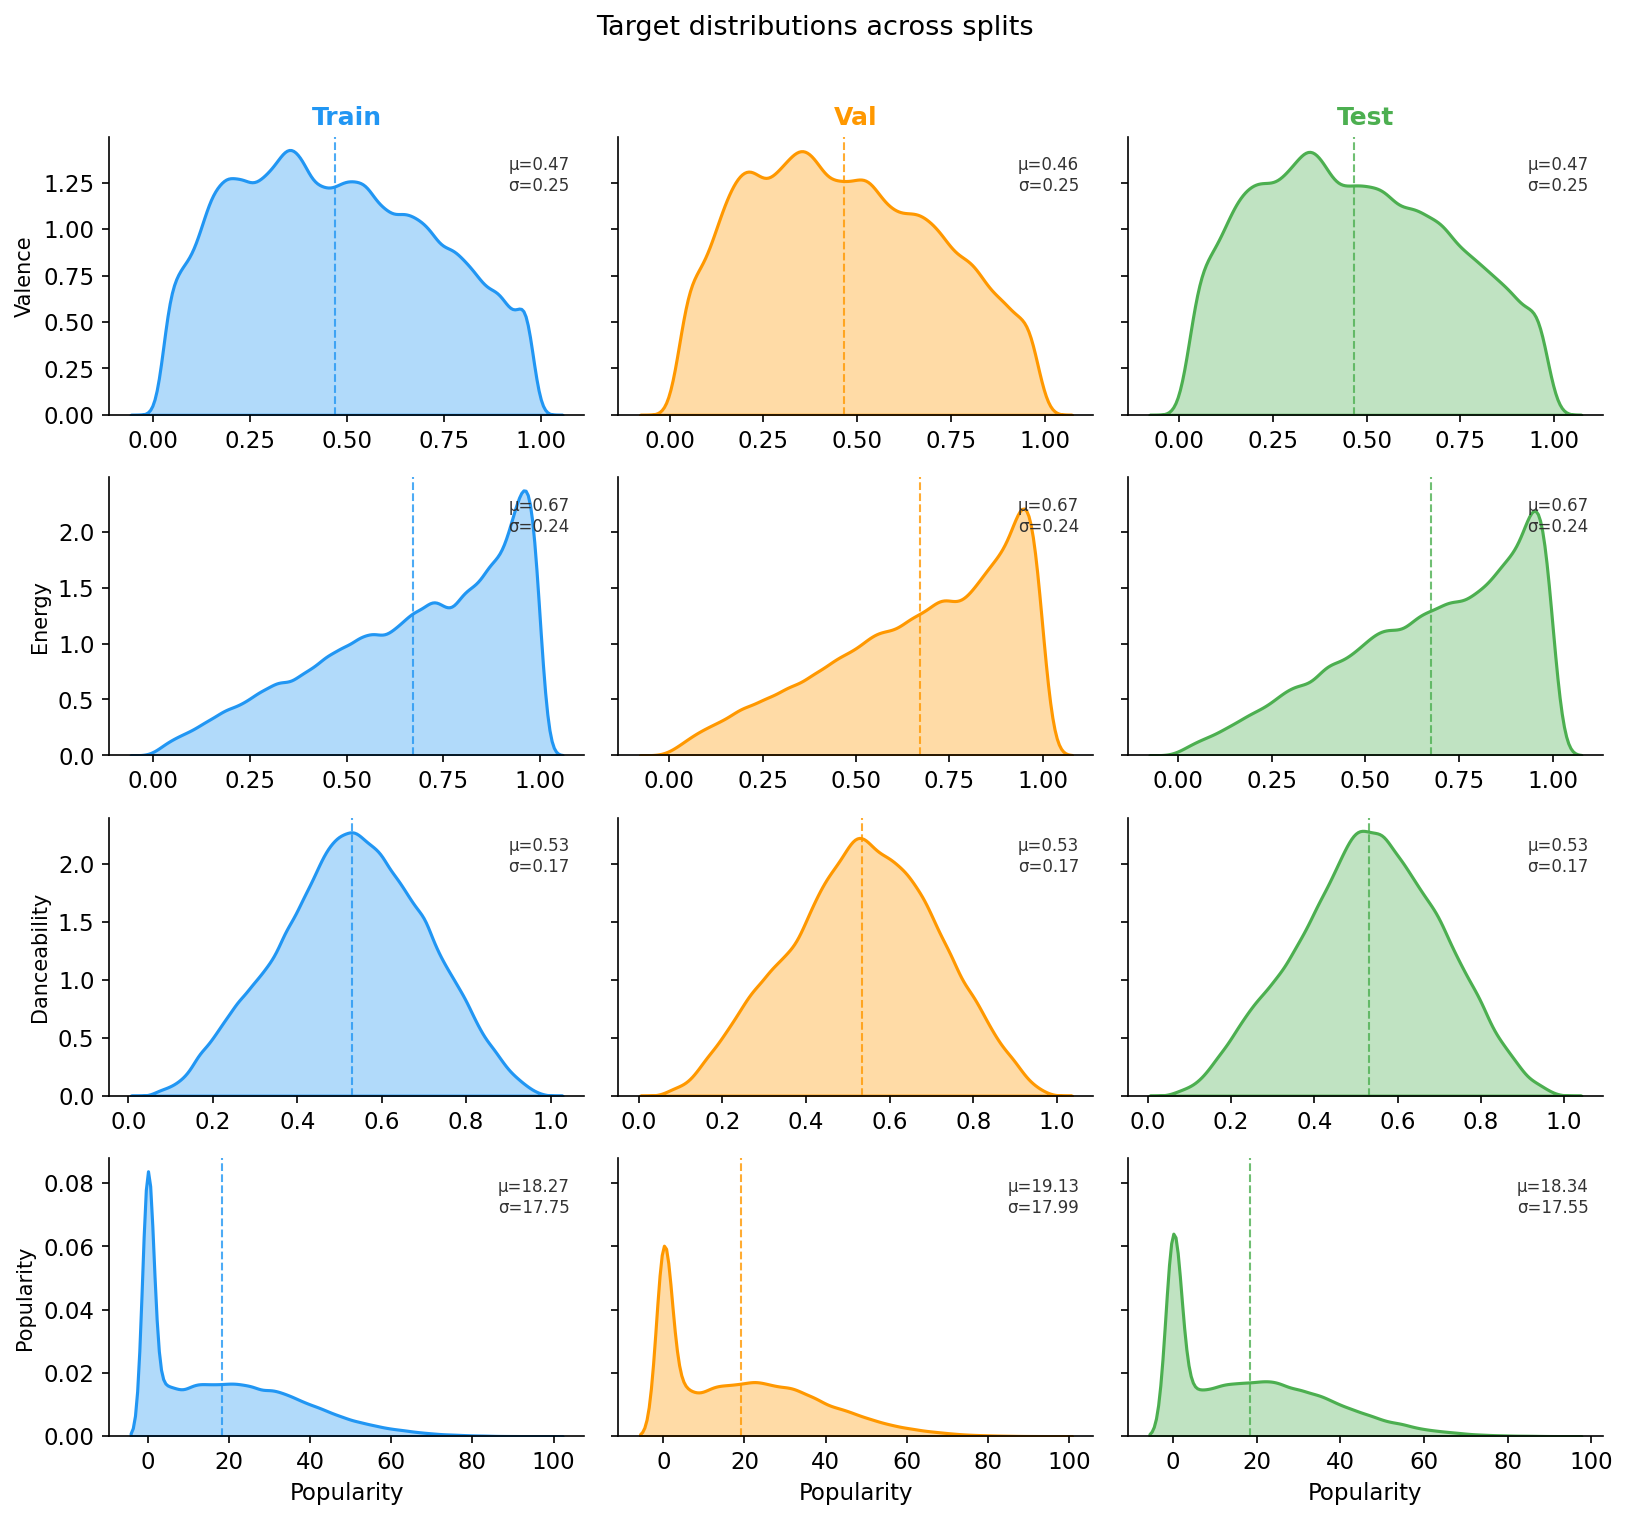

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(11, 10), sharey='row')

for row, target in enumerate(TARGETS):
    for col, split in enumerate(SPLITS):
        ax  = axes[row, col]
        ser = dfs[split][target].dropna()

        # KDE with fallback to histogram for very sparse ranges
        try:
            sns.kdeplot(
                ser, ax=ax,
                color=SPLIT_COLORS[split],
                fill=True, alpha=0.35,
                linewidth=1.5,
            )
        except Exception:
            ax.hist(ser, bins=30, color=SPLIT_COLORS[split], alpha=0.6, density=True)

        ax.set_xlabel(target.capitalize() if row == 3 else '')
        if col == 0:
            ax.set_ylabel('Density')
        if row == 0:
            ax.set_title(split.capitalize(), color=SPLIT_COLORS[split], fontweight='bold')

        # Stats annotation
        mu, sd = ser.mean(), ser.std()
        ax.axvline(mu, color=SPLIT_COLORS[split], linestyle='--', linewidth=1, alpha=0.8)
        ax.text(
            0.97, 0.93,
            f'μ={mu:.2f}\nσ={sd:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=8,
            color='#333333',
        )

        # Row label on leftmost column
        if col == 0:
            ax.set_ylabel(target.capitalize(), fontsize=10)

fig.suptitle('Target distributions across splits', fontsize=13, y=1.01)
plt.tight_layout()
out = FIGS / '10_target_distributions.png'
fig.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

## 4. Figure 3 — Target Correlation Heatmap (Test Set)

Pairwise Pearson correlations among targets in the held-out test set.
Low inter-target correlation supports treating each as an independent prediction task.

Saved: /home/esstee/projects/music-prediction/results/figures/thesis/10_target_correlation.png


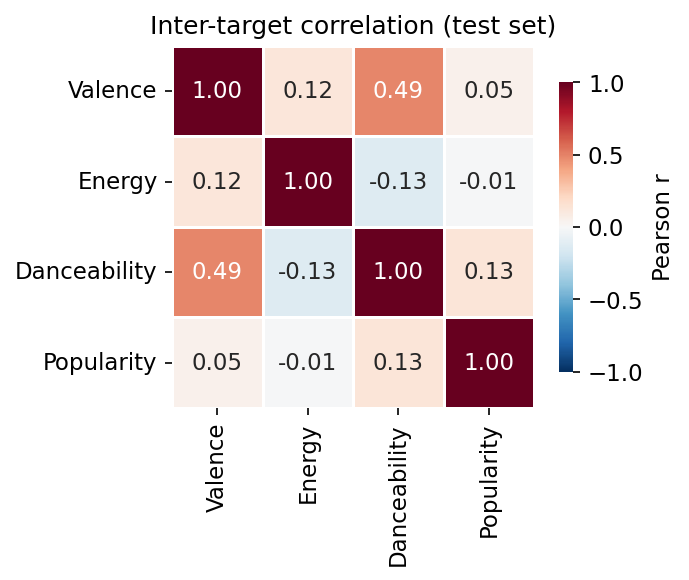


Correlation matrix (test set):
              valence  energy  danceability  popularity
valence         1.000   0.118         0.486       0.048
energy          0.118   1.000        -0.128      -0.015
danceability    0.486  -0.128         1.000       0.128
popularity      0.048  -0.015         0.128       1.000


In [5]:
corr = dfs['test'][TARGETS].corr()

fig, ax = plt.subplots(figsize=(5, 4))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    xticklabels=[t.capitalize() for t in TARGETS],
    yticklabels=[t.capitalize() for t in TARGETS],
)

ax.set_title('Inter-target correlation (test set)')
plt.tight_layout()
out = FIGS / '10_target_correlation.png'
fig.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

print('\nCorrelation matrix (test set):')
print(corr.round(3).to_string())

## 5. Figure 4 — Genre & Year Coverage (Training Set)

Left: top 15 genres by sample count (training data only).  
Right: release-year distribution showing temporal breadth of the corpus.

Saved: /home/esstee/projects/music-prediction/results/figures/thesis/10_genre_year_coverage.png


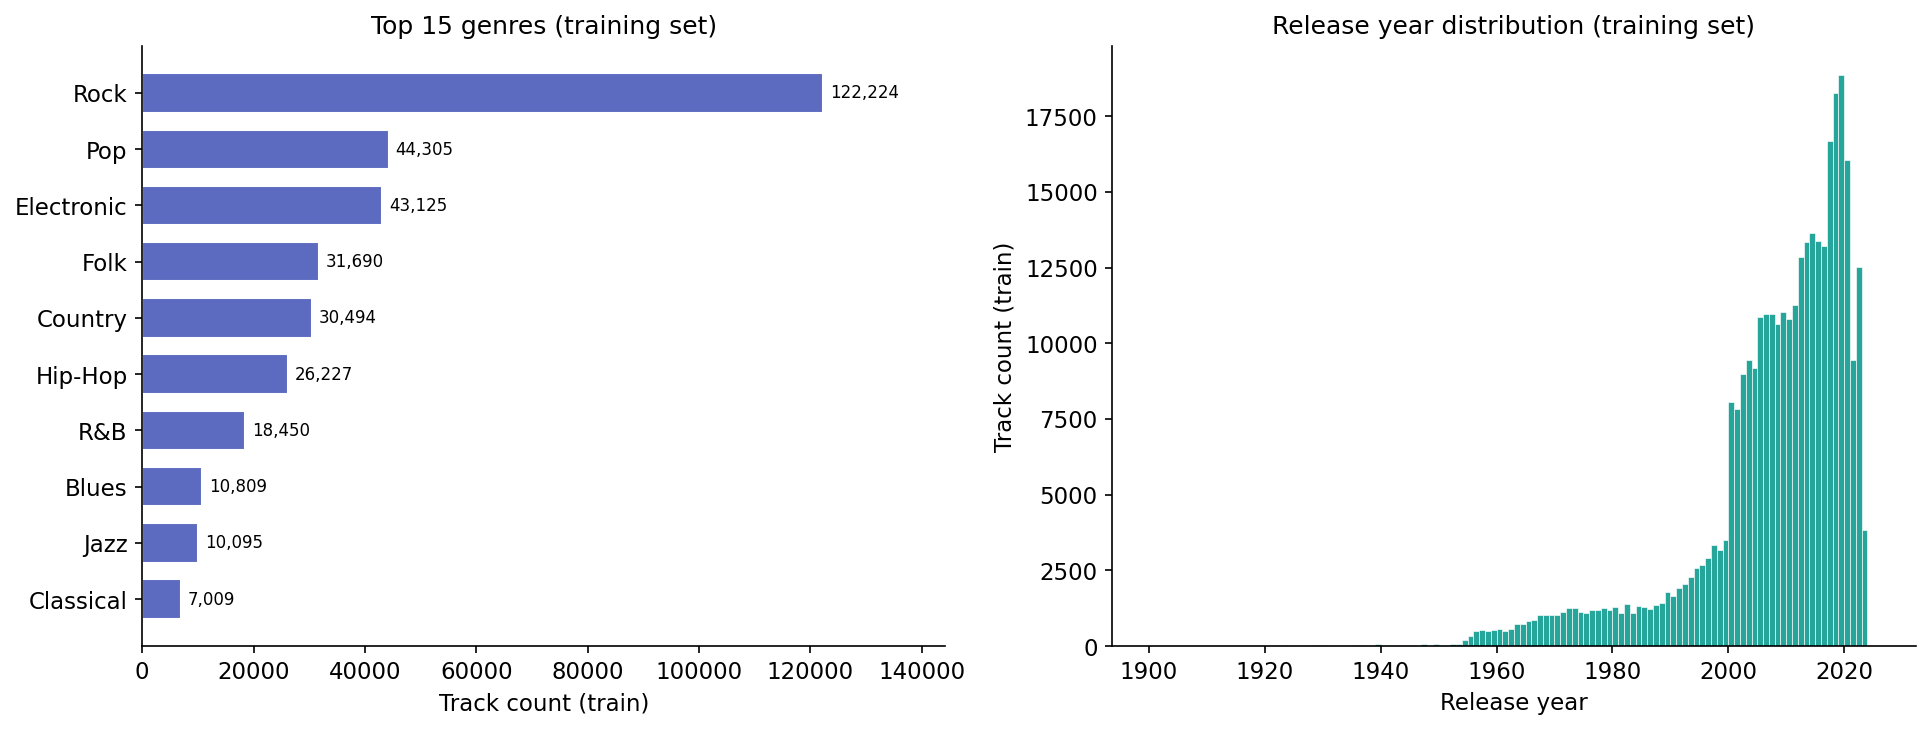

In [6]:
train = dfs['train'].copy()

# --- Genre panel ---
genre_counts = (
    train[GENRE_COL]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()          # ascending so top bar is at the top of hbar
)

# --- Year panel ---
if YEAR_COL == 'release_date':
    # Extract 4-digit year from string if needed
    year_series = pd.to_datetime(train[YEAR_COL], errors='coerce').dt.year.dropna()
else:
    year_series = pd.to_numeric(train[YEAR_COL], errors='coerce').dropna()

year_series = year_series[(year_series >= 1900) & (year_series <= 2030)]

# --- Plot ---
fig, (ax_genre, ax_year) = plt.subplots(1, 2, figsize=(13, 5))

# Genre bar chart
ax_genre.barh(
    genre_counts.index,
    genre_counts.values,
    color='#5C6BC0',
    edgecolor='white',
    height=0.7,
)
ax_genre.set_xlabel('Track count (train)')
ax_genre.set_title('Top 15 genres (training set)')
for i, (val, lbl) in enumerate(zip(genre_counts.values, genre_counts.index)):
    ax_genre.text(
        val + genre_counts.max() * 0.01, i,
        f'{val:,}', va='center', fontsize=8
    )
ax_genre.set_xlim(0, genre_counts.max() * 1.18)

# Year histogram
bins = range(int(year_series.min()), int(year_series.max()) + 2)
ax_year.hist(
    year_series,
    bins=bins,
    color='#26A69A',
    edgecolor='white',
    linewidth=0.3,
)
ax_year.set_xlabel('Release year')
ax_year.set_ylabel('Track count (train)')
ax_year.set_title('Release year distribution (training set)')

plt.tight_layout()
out = FIGS / '10_genre_year_coverage.png'
fig.savefig(out, bbox_inches='tight')
print('Saved:', out)
plt.show()

## 6. Artist-Aware Split Sanity Check

Measures the fraction of artists in each split that also appear in every other split.
Ideally, val/test artists should have minimal overlap with train to avoid data leakage via artist-level stylistic signal.

In [7]:
import ast

def extract_artists(series):
    """Return a flat set of artist strings from a column that may contain lists."""
    artists = set()
    for val in series.dropna():
        if isinstance(val, str):
            # Try to parse as Python list literal, e.g. '["Artist A", "Artist B"]'
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, list):
                    artists.update(str(a).strip() for a in parsed)
                else:
                    artists.add(val.strip())
            except Exception:
                artists.add(val.strip())
        elif isinstance(val, list):
            artists.update(str(a).strip() for a in val)
    return artists


artist_sets = {s: extract_artists(dfs[s][ARTIST_COL]) for s in SPLITS}

print('Artist counts per split:')
for s in SPLITS:
    print(f'  {s:>5}: {len(artist_sets[s]):>6,} unique artists')

print()

# Overlap pairs
pairs = [
    ('train', 'val'),
    ('train', 'test'),
    ('val',   'test'),
]

rows = []
for a, b in pairs:
    intersection = artist_sets[a] & artist_sets[b]
    frac_a = len(intersection) / len(artist_sets[a]) if artist_sets[a] else 0
    frac_b = len(intersection) / len(artist_sets[b]) if artist_sets[b] else 0
    rows.append({
        'Split A': a,
        'Split B': b,
        'Shared artists': len(intersection),
        f'% of {a}': f'{100*frac_a:.1f}%',
        f'% of {b}': f'{100*frac_b:.1f}%',
    })

overlap_df = pd.DataFrame(rows)
print('Artist overlap between splits:')
print(overlap_df.to_string(index=False))

Artist counts per split:
  train: 47,102 unique artists
    val: 13,326 unique artists
   test: 12,998 unique artists

Artist overlap between splits:
Split A Split B  Shared artists % of train % of val % of test
  train     val            5493      11.7%    41.2%       NaN
  train    test            5204      11.0%      NaN     40.0%
    val    test            2485        NaN    18.6%     19.1%


## 7. Summary

**Key findings from this EDA:**

- **Split sizes**: The dataset follows the expected train-dominant distribution. Absolute sample counts in val and test are reported in Figure 1.
- **Target stationarity**: Per-split KDE plots (Figure 2) show consistent mean and standard deviation across train, val, and test for all four targets, indicating that the splitting procedure did not introduce distributional shift.
- **Inter-target independence**: The correlation heatmap (Figure 3) quantifies how much the targets share variance. Low off-diagonal values support treating each target as an independent regression problem; notable correlations (e.g., energy–valence) inform multi-task learning design choices.
- **Genre and year coverage**: The training corpus spans a broad range of genres and decades (Figure 4), reducing the risk of genre-specific or temporal confounding.
- **Artist leakage**: The sanity check quantifies the fraction of val/test artists seen during training. Any overlap is noted and should be factored into interpretation of model generalisation.